# Simple Linear Regression

In [27]:
import pandas as pd
import  matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
%matplotlib inline

In [28]:
df = pd.read_csv('./DATA/height-weight.csv')

In [29]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


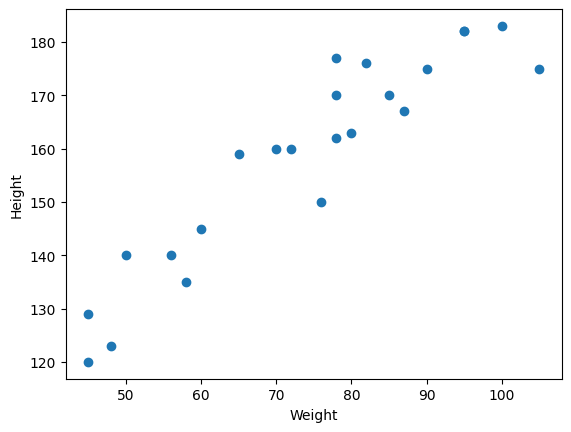

In [30]:
## scatter plot 
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()
# show weight increase and height also increase 

In [31]:
## correlation
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


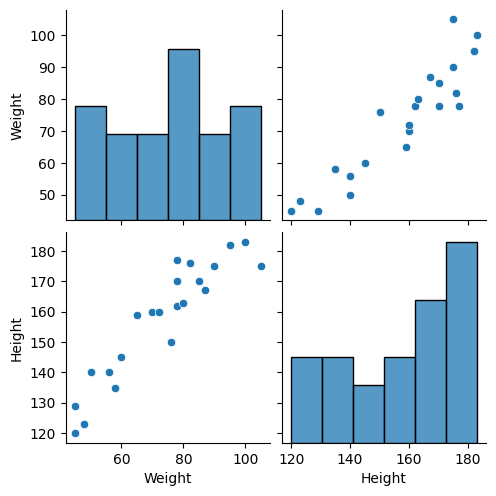

In [32]:
## sns for visualisation
sns.pairplot(df)

In [33]:
# ## independent and dependent feature 
# X=df[['Weight']]# independent features should be data frame or 2D array
# # print(type(X))
# # print(type(df))
# np.array(X).shape # for training always in this fromat

In [34]:
X_series=df['Weight']
np.array(X_series).shape # not in this format

(23,)

In [35]:
## independent and dependent feature 
X=df[['Weight']]# independent features should be data frame or 2D array
y=df['Height'] # dependent feature

In [36]:
np.array(y).shape

(23,)

In [37]:
## Train Test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42) # random_state if we dont fix the random_state then every time diff train/test data set run , model accuracy change , result become unpredictable , unproducible

In [38]:
X_train.shape

(17, 1)

In [39]:
y_test.shape

(6,)

In [40]:
## Standardization
from sklearn.preprocessing import StandardScaler

In [41]:
## std input feature --> only for independent features 
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)

1. X_train there we use fit_transformI() where we find the mean, std and z value for training the data set 
2. in X_test we use same mean, std used in training , on the behalf  we transform() the test data , help  in prediction 
3. preventing the data leakage 

In [42]:
X_test=scaler.transform(X_test)

In [43]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [44]:

covariances = [np.cov(X_train[:, i], y_train)[0, 1] for i in range(X_train.shape[1])]
print(covariances)

[np.float64(18.379343560885747)]


In [48]:
print(np.std(df))

Weight    17.479559
Height    19.082747
dtype: float64


c:\Users\91742\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:4062: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)


In [45]:
## Apply simple linear regression 
from sklearn.linear_model import LinearRegression

In [46]:
regression = LinearRegression(n_jobs=-1)

In [47]:
regression.fit(X_series,y_train) # giving error if we use 1d array 

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [ ]:
regression.fit(X_train,y_train)

LinearRegression(n_jobs=-1)

In [ ]:
print("Coefficient or slope:",regression.coef_) #1 becuz only one independent feature  <-- B1(beta one) , x -> weight
print("intercept :", regression.intercept_)

Coefficient or slope: [18.10270485]
intercept : 153.88235294117646


1. 1 unit movement in the weight value [18.10270485] that much change in height value 
2. when weight value is 0 at [153.88235294117646] this value it meeting intercept y

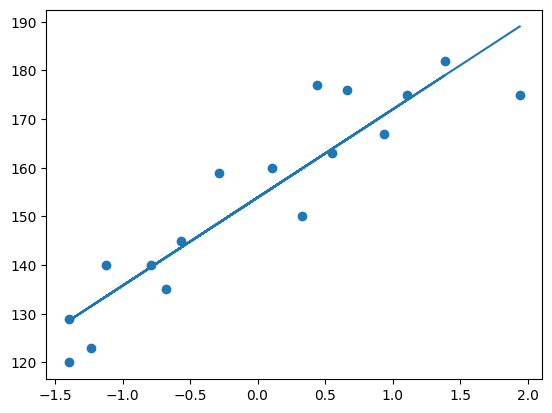

In [ ]:
## plot training data plot best fit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

# Prediction of test data 
1. predicted height output = intercept + coef_ * (weights)
2. y_pred_Test = 156 + 18.3(X_test)

In [ ]:
## prediction for test data 
y_pred=regression.predict(X_test)

In [ ]:
## performance metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("mse",mse)
print("mae",mae)
print("rmse",rmse)

mse 19.540624418156032
mae 3.2905881175520286
rmse 4.420477849526681


# R square 
R^2=1-SSR/SST

In [ ]:
from sklearn.metrics import r2_score

In [ ]:
score = r2_score(y_test,y_pred)
print(score)

0.7499244653204347


# Adjusted R^2 = 1- [(1-R^2)*(n-1) / (n-k-1)]

In [ ]:
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6874055816505433

# OLS linear regression

In [ ]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------- ----------------------------- 2.6/9.6 MB 14.6 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 21.2 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 19.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import statsmodels.api as sm

In [ ]:
model = sm.OLS(y_train,X_train).fit()

In [ ]:
prediction=model.predict(X_test)
print(prediction)

[ 7.94337783 30.11370102 -0.11855788 25.0749912   7.94337783 14.99757157]


In [ ]:
print(model.summary()) # ols and linear work as same stretargy

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.014
Model:                            OLS   Adj. R-squared (uncentered):             -0.048
Method:                 Least Squares   F-statistic:                             0.2209
Date:                Tue, 25 Nov 2025   Prob (F-statistic):                       0.645
Time:                        21:52:17   Log-Likelihood:                         -109.76
No. Observations:                  17   AIC:                                      221.5
Df Residuals:                      16   BIC:                                      222.4
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

c:\Users\91742\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=17 observations were given.
  return hypotest_fun_in(*args, **kwds)


# Prediction

In [ ]:
## prediction for new data 
regression.predict(scaler.transform([[72]]))

c:\Users\91742\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.77927899])

In [ ]:
model.predict(scaler.transform([[72]])) ## showing wrong ans  not provide intersept

c:\Users\91742\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([1.89692605])

# Prediction from OLS model 

In [ ]:
import statsmodels.api as sm

X_train_ols = sm.add_constant(X_train)      # add intercept
model = sm.OLS(y_train, X_train_ols).fit()

X_test_ols = sm.add_constant(X_test)
prediction = model.predict(X_test_ols)


In [ ]:
scaled = scaler.transform([[72]])
scaled_const = sm.add_constant(scaled, has_constant='add')
prediction = model.predict(scaled_const)
print(prediction)


[155.77927899]


c:\Users\91742\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
